# 05 Create SFINCS Scenarios

In [1]:
import sys
from pathlib import Path
import pandas as pd

location_root = Path("..").resolve()
repo_root = location_root.parents[1]
src_root = repo_root / "src"
sys.path.insert(0, str(src_root))

from sfincs_runs.config import load_sfincs_runtime as load_runtime
from sfincs_runs.scenarios.create_events import build_scenarios, parse_args

runtime = load_runtime(location_root, wave=True, create_base_model_dir=False)
paths = runtime.paths
scenario_limit = None
design_scenarios = ["base", "noaa_int_2050", "noaa_int_2100"]
rerun = True
n_jobs = 8 # worker processes for staging events (1 = serial; lower this if memory is tight)

## Package Scenario Folders


In [2]:
reports = {}
summary_rows = []
for design_scenario in design_scenarios:
    builder_argv = [
        "--config", str(paths["location_config_path"]),
        "--design-scenario", design_scenario,
        "--full-forcing",
        "--zsini-mode", "boundary_t0",
        "--jobs", str(n_jobs),
    ]
    if scenario_limit is not None:
        builder_argv.extend(["--limit", str(scenario_limit)])
    builder_argv.append("--force" if rerun else "--resume")

    report = build_scenarios(parse_args(builder_argv))
    reports[design_scenario] = report
    scenario_root = paths["scenarios_root"] if design_scenario == "base" else paths["scenarios_root"].with_name(f"{paths['scenarios_root'].name}_{design_scenario}")
    summary_rows.append({
        "design_scenario": design_scenario,
        "scenario_catalog": str(scenario_root / "scenario_catalog.csv"),
        "scenario_count": len(report),
    })

scenario_build_summary = pd.DataFrame(summary_rows).set_index("design_scenario")
scenario_build_summary

  staging 514 events across 8 worker processes
2026-06-26 16:54:57,523 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0rc1).
2026-06-26 16:54:57,523 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0rc1).
2026-06-26 16:54:57,523 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0rc1).
2026-06-26 16:54:57,523 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0rc1).
2026-06-26 16:54:57,526 - hydromt.model.model - model - WARNING - No region component found in components.
2026-06-26 16:54:57,526 - hydromt.model.model - model - WARNING - No region component found in components.
2026-06-26 16:54:57,527 - hydromt.model.model - model - WARNING - No region component found in components.
2026-06-26 16:54:57,523 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0rc1).
2026-06-26 16:54:57,52

,scenario_catalog,scenario_count
design_scenario,,
base,/home/grahamhults/projects/Flood-RM/locations/...,514
noaa_int_2050,/home/grahamhults/projects/Flood-RM/locations/...,514
noaa_int_2100,/home/grahamhults/projects/Flood-RM/locations/...,514


## Sync Handoff


In [3]:
print(f"SYNC_LOCATION={runtime.location_name} cluster/sync_to_dsai.sh --run-inputs-only")
print("See cluster/instructions.txt for submit and retrieve commands.")

SYNC_LOCATION=marshfield cluster/sync_to_dsai.sh --run-inputs-only
See cluster/instructions.txt for submit and retrieve commands.


## Validate Forcing Variables of Randomly Sampled Event

PosixPath('/home/grahamhults/projects/Flood-RM/locations/marshfield/data/sfincs/scenarios/design_0436')

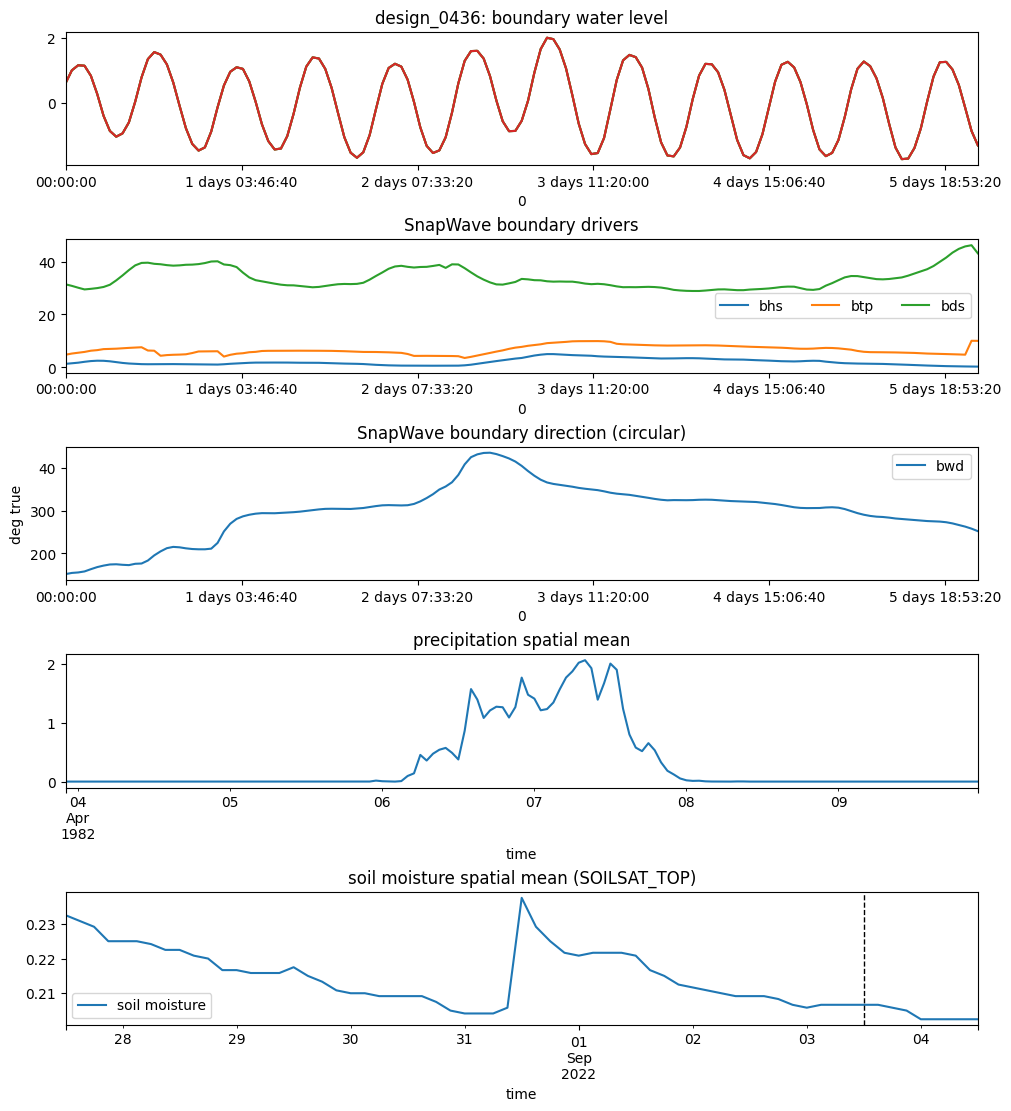

In [10]:
import json
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.ticker import FuncFormatter

scenarios_root = getattr(runtime, "sfincs_scenarios_root", None)
if scenarios_root is None:
    scenarios_root = paths["scenarios_root"]
manifest_paths = sorted(Path(scenarios_root).rglob("forcing_manifest.json"))
if not manifest_paths:
    raise FileNotFoundError(f"No forcing_manifest.json files under {scenarios_root}")
manifest_path = pd.Series(manifest_paths).sample(1).iloc[0]
event_dir = manifest_path.parent
m = json.loads(manifest_path.read_text())

def resolve_manifest_path(value):
    if not value:
        return None
    path = Path(value)
    if path.exists():
        return path
    if not path.is_absolute():
        candidate = location_root / path
        return candidate if candidate.exists() else path
    parts = path.parts
    if location_root.name in parts:
        candidate = location_root / Path(*parts[parts.index(location_root.name) + 1:])
        return candidate if candidate.exists() else path
    return path

def dataset_mean_series(path):
    with xr.open_dataset(path) as ds:
        da = ds[next(iter(ds.data_vars))]
        return da.mean([d for d in da.dims if d != "time"]).to_series()

def circular_mean_degrees(frame):
    theta = np.deg2rad(frame.astype(float))
    mean_sin = np.sin(theta).mean(axis=1)
    mean_cos = np.cos(theta).mean(axis=1)
    return pd.Series((np.rad2deg(np.arctan2(mean_sin, mean_cos)) + 360.0) % 360.0, index=frame.index)

def unwrap_direction_degrees(series):
    return pd.Series(np.rad2deg(np.unwrap(np.deg2rad(series.astype(float)))), index=series.index)

panels = []
if (event_dir / "sfincs.bzs").exists():
    wl = pd.read_csv(event_dir / "sfincs.bzs", sep=r"\s+", header=None).set_index(0)
    wl.index = pd.to_timedelta(wl.index, unit="s")
    panels.append((f"{event_dir.name}: boundary water level", [(wl, None)]))
snap = []
bwd_unwrapped = None
for fn in ["snapwave.bhs", "snapwave.btp", "snapwave.bds"]:
    if (event_dir / fn).exists():
        s = pd.read_csv(event_dir / fn, sep=r"\s+", header=None).set_index(0).mean(axis=1)
        s.index = pd.to_timedelta(s.index, unit="s")
        snap.append((s, fn.replace("snapwave.", "")))
if snap:
    panels.append(("SnapWave boundary drivers", snap))
if (event_dir / "snapwave.bwd").exists():
    bwd = pd.read_csv(event_dir / "snapwave.bwd", sep=r"\s+", header=None).set_index(0)
    bwd.index = pd.to_timedelta(bwd.index, unit="s")
    bwd_unwrapped = unwrap_direction_degrees(circular_mean_degrees(bwd))
    panels.append(("SnapWave boundary direction (circular)", [(bwd_unwrapped, "bwd")]))
discharge_path = resolve_manifest_path(m.get("wflow_discharge_forcing"))
if discharge_path and discharge_path.exists():
    panels.append(("Wflow-SFINCS discharge spatial/source mean", [(dataset_mean_series(discharge_path), None)]))
precip_path = event_dir / m.get("netamprfile", "sfincs_netampr.nc")
if precip_path.exists():
    panels.append(("precipitation spatial mean", [(dataset_mean_series(precip_path), None)]))
sm_path = resolve_manifest_path(m.get("soil_moisture_member_file"))
sm_time = m.get("soil_moisture_member_time") or m.get("event_reference_time") or m.get("rainfall_member_time") or m.get("run_start")
if sm_path and sm_path.exists() and sm_time:
    sm_t = pd.Timestamp(sm_time)
    var = m.get("soil_moisture_summary", {}).get("soil_moisture_variable", "SOILSAT_TOP")
    sm = pd.read_csv(sm_path, usecols=["time", var], parse_dates=["time"])
    sm = sm[sm["time"].between(sm_t - pd.Timedelta(days=7), sm_t + pd.Timedelta(days=1))]
    panels.append((f"soil moisture spatial mean ({var})", [(sm.groupby("time")[var].mean(), "soil moisture")]))

fig, axes = plt.subplots(len(panels), 1, figsize=(10, max(2.2 * len(panels), 4)), constrained_layout=True)
if len(panels) == 1:
    axes = [axes]
for ax, (title, series_items) in zip(axes, panels):
    for series, label in series_items:
        series.plot(ax=ax, label=label, legend=False)
    ax.set_title(title)
    if title == "SnapWave boundary direction (circular)":
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y % 360:.0f}"))
        ax.set_ylabel("deg true")
    if any(label for _, label in series_items):
        ax.legend(ncol=min(len(series_items), 4))
if sm_path and sm_path.exists() and sm_time and panels:
    axes[-1].axvline(pd.Timestamp(sm_time), color="k", ls="--", lw=1)
event_dir